# Advanced House Price Analysis

## Extended Data Science Exploration

This notebook contains additional analyses and experiments performed beyond the assignment requirements. The objective is to gain deeper insights into the housing dataset, evaluate model behavior, and explore potential future improvements.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

In [2]:
df = pd.read_csv("Housing_Cleaned.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Feature Correlation Analysis

This section identifies which features have the strongest relationship with house price.

In [3]:
price_corr = df.corr()["price"].sort_values(
    ascending=False
)

price_corr

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

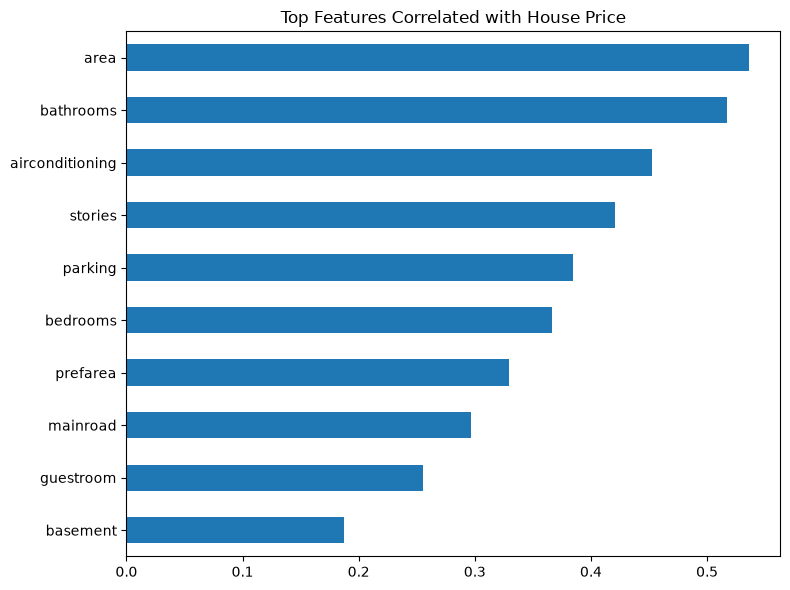

In [17]:
plt.figure(figsize=(8,6))

price_corr.drop("price").head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top Features Correlated with House Price")

plt.tight_layout()
plt.savefig("charts/top_feature_correlation.png", dpi=300)
plt.show()

## Relationship Between Area and House Price

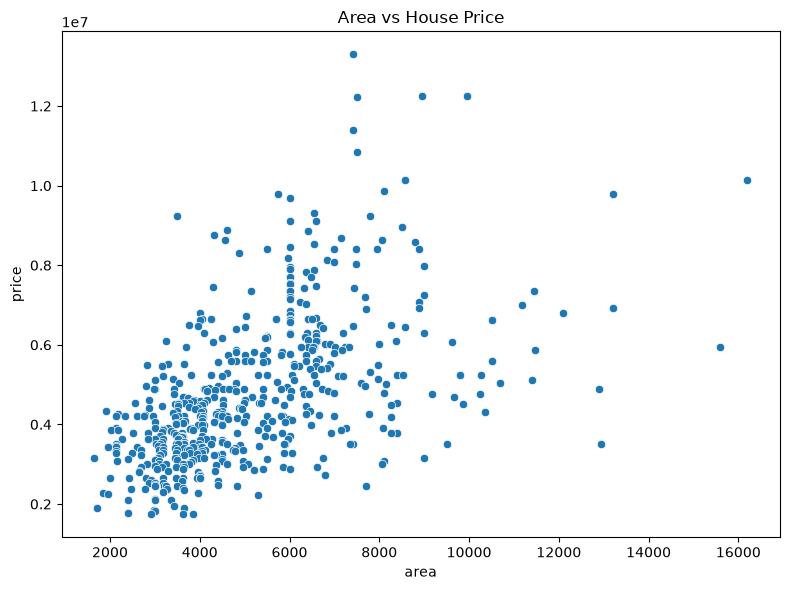

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="area",
    y="price"
)

plt.title("Area vs House Price")

plt.tight_layout()
plt.savefig("charts/area_vs_price.png", dpi=300)
plt.show()

Model Comparison Visualization

In [6]:
models = ["Linear Regression", "Random Forest"]

scores = [0.6529, 0.6124]

comparison_df = pd.DataFrame({
    "Model": models,
    "R2 Score": scores
})

comparison_df

,Model,R2 Score
0,Linear Regression,0.6529
1,Random Forest,0.6124


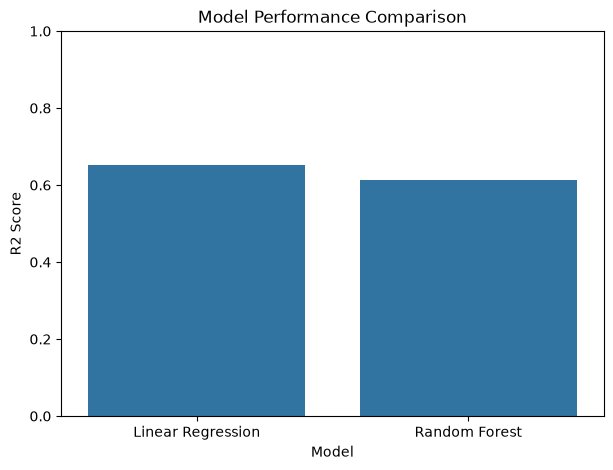

In [19]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison")

plt.ylim(0,1)
plt.savefig("charts/model_comparison.png", dpi=300)

plt.show()

# Example Prediction Demonstration

In [11]:
import pickle

with open("models/house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [12]:
# recreate test data
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
# generate prediction
lr_predictions = loaded_model.predict(X_test)

In [14]:
#example

prediction_demo = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": lr_predictions[:10]
})

prediction_demo["Difference"] = (
    prediction_demo["Actual Price"] -
    prediction_demo["Predicted Price"]
).abs()

prediction_demo

,Actual Price,Predicted Price,Difference
0,4060000,5.164654e+06,1.104654e+06
1,6650000,7.224722e+06,5.747223e+05
2,3710000,3.109863e+06,6.001368e+05
3,6440000,4.612075e+06,1.827925e+06
4,2800000,3.294646e+06,4.946463e+05
5,4900000,3.532275e+06,1.367725e+06
6,5250000,5.611775e+06,3.617746e+05
7,4543000,6.368146e+06,1.825146e+06
8,2450000,2.722857e+06,2.728570e+05
9,3353000,2.629406e+06,7.235944e+05


In [15]:
prediction_demo = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": lr_predictions
})

prediction_demo["Difference"] = (
    prediction_demo["Actual Price"] -
    prediction_demo["Predicted Price"]
).abs()

prediction_demo.sort_values(
    by="Difference"
).head(10)

,Actual Price,Predicted Price,Difference
13,3360000,3.394639e+06,34639.091255
86,2660000,2.607277e+06,52722.618237
32,6650000,6.708457e+06,58457.367613
52,4270000,4.341751e+06,71750.614205
27,5110000,5.191899e+06,81898.799342
61,3500000,3.584360e+06,84359.560149
36,4900000,4.808661e+06,91339.325515
58,4340000,4.239582e+06,100417.940398
81,4165000,4.053241e+06,111758.882242
77,4830000,4.714056e+06,115943.632920
